In [2]:
import os
import datetime

import IPython
import IPython.display
import matplotlib as mpl
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import tensorflow as tf

mpl.rcParams['figure.figsize'] = (12, 6)
mpl.rcParams['axes.grid'] = False

2026-02-13 12:37:08.244084: I external/local_xla/xla/tsl/cuda/cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
2026-02-13 12:37:08.244303: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-02-13 12:37:08.294392: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI AVX512_BF16 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2026-02-13 12:37:09.321303: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation or

# Preprocessing & Feature engineering

In [3]:
df = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month_day.csv')
df = df.drop(columns=['unique_entry_per_day', 'total_admittances'])
first_value = df['total_encounters'].iloc[0]
df['detrended_te'] = df['total_encounters'].diff(1)
display(df.dropna(inplace=True))
date_time = pd.to_datetime(df.pop('Date'), format='%Y-%m-%d')


None

#### FFT to encode clock

array([<Axes: >, <Axes: >], dtype=object)

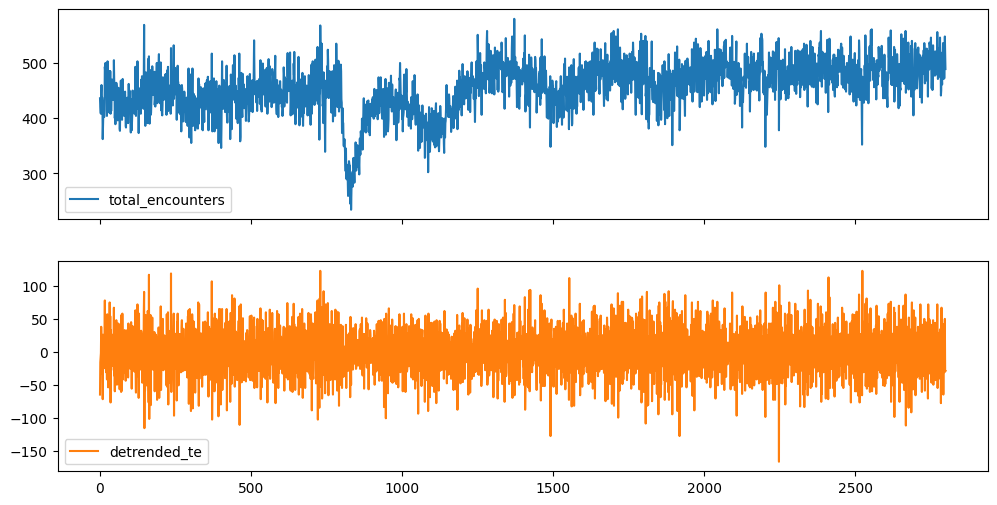

In [4]:
timestamp_s = date_time.map(pd.Timestamp.timestamp) # we convert to seconds
df.plot(subplots=True)


2026-02-13 12:37:09.791085: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


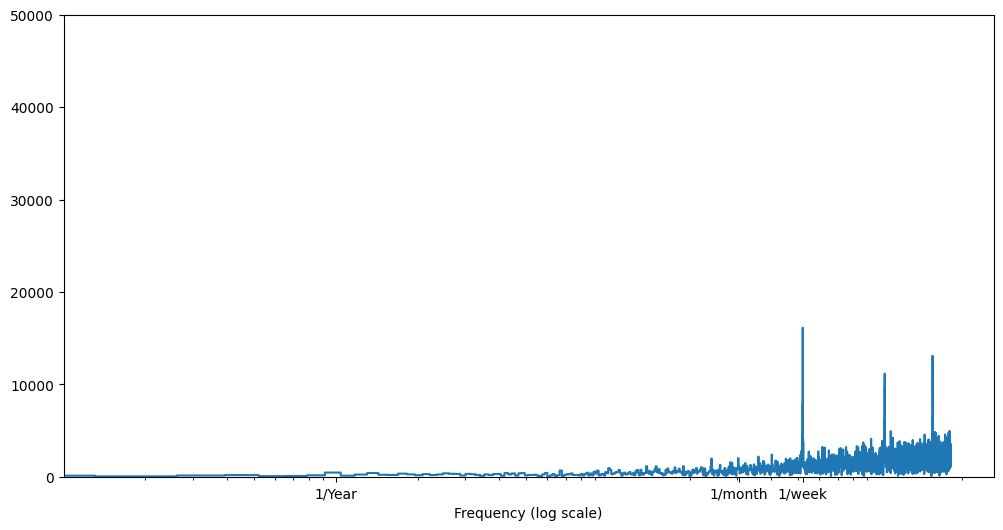

In [5]:
fft = tf.signal.rfft(df['detrended_te'])
f_per_dataset = np.arange(0, len(fft))

n_samples_h = len(df['detrended_te'])
days_per_year = 365.2524
years_per_dataset = n_samples_h/(days_per_year)

f_per_year = f_per_dataset/years_per_dataset
plt.step(f_per_year, np.abs(fft))
plt.xscale('log')
plt.ylim(0, 50000)
plt.xlim([0.1, max(plt.xlim())])
plt.xticks([1, 365.2524/12, 365.2524/7], labels=['1/Year', '1/month', '1/week'])
_ = plt.xlabel('Frequency (log scale)')

In [6]:
day = 24 * 60 * 60
week = 7 * day
year = 365.2425 * day

# first week harmonic 
df['week_sin_1'] = np.sin(2 * np.pi * timestamp_s / week)
df['week_cos_1'] = np.cos(2 * np.pi * timestamp_s / week)
# second week harmonic
df['week_sin_2'] = np.sin(2 * np.pi * 2 * timestamp_s / week)
df['week_cos_2'] = np.cos(2 * np.pi * 2 * timestamp_s / week)
# third week harmonic
df['week_sin_3'] = np.sin(2 * np.pi * 3 * timestamp_s / week)
df['week_cos_3'] = np.cos(2 * np.pi * 3 * timestamp_s / week)

In [7]:
df = df.drop('detrended_te', axis=1)

array([<Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >, <Axes: >,
       <Axes: >], dtype=object)

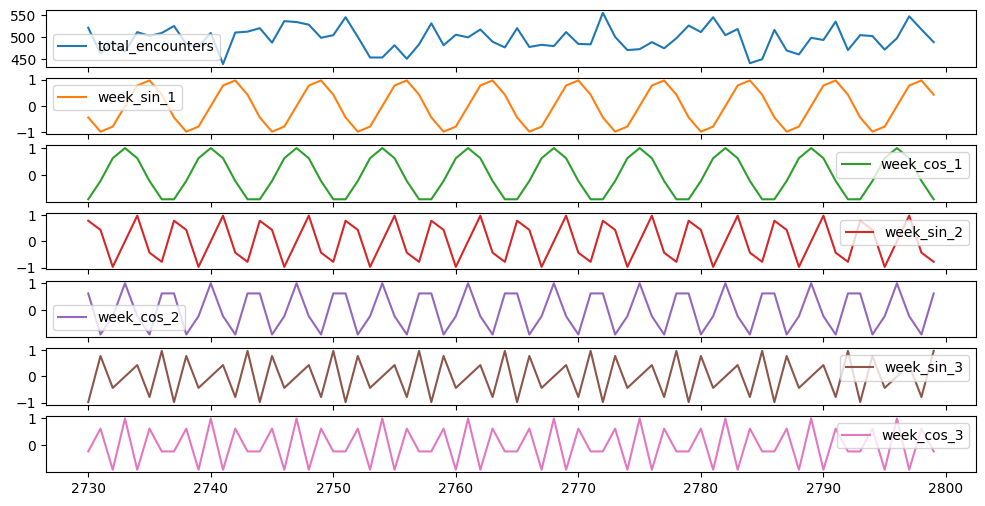

In [8]:
df[-70:].plot(subplots=True)

#### Split Data

In [9]:
column_indices = {name: i for i, name in enumerate(df.columns)}
num_features = df.shape[1]

n = len(df)
train_df = df[0:int(n*0.7)]
val_df = df[int(n*0.7):int(n*0.9)]
test_df = df[int(n*0.9):]

#### Normalize z-score

In [10]:
train_mean = train_df.mean()
train_std = train_df.std()

train_df = (train_df - train_mean) / train_std
val_df = (val_df - train_mean) / train_std
test_df = (test_df - train_mean) / train_std

# Env Variables

In [11]:
# Env variables

BATCH_SIZE = 64

MAX_EPOCHS = 100
LR = 7e-4

LOOK_BACK = 28
OUT_STEPS = 7

# CNN
CONV_WIDTH = 14

# AR-LSTM
UNITS = 32



# Window Generator class

In [12]:
class WindowGenerator():
    def __init__(self, input_width, label_width, shift,
                 train_df=train_df, val_df=val_df, test_df=test_df,
                 label_columns=None, batch_size=BATCH_SIZE):
        
        self.train_df = train_df
        self.val_df = val_df
        self.test_df = test_df
        self.batch_size = batch_size

        self.label_columns = label_columns
        if label_columns is not None:
            self.label_columns_ids = {name: i for i, name in 
                                      enumerate(label_columns)}
        
        self.column_ids = {name: i for i, name in
                           enumerate(train_df.columns)}
        
        self.input_width = input_width
        self.label_width = label_width
        self.shift = shift

        self.total_window_size = input_width + shift

        # Work out input ids
        self.input_slice = slice(0, input_width)
        self.input_ids = np.arange(self.total_window_size)[self.input_slice]

        # Work out label ids
        self.labels_start = self.total_window_size - label_width
        self.label_slice = slice(self.labels_start, None)
        self.label_ids = np.arange(self.total_window_size)[self.label_slice]



    def __repr__(self):
        return '\n'.join([
            f'Total window size: {self.total_window_size}',
            f'Input indices: {self.input_ids}',
            f'Label indices: {self.label_ids}',
            f'Label column name(s): {self.label_columns}'])
    
    def split_window(self, features):
        # features.shape = (batch_size, time, features)
        inputs = features[:, self.input_slice, :]
        labels = features[:, self.label_slice, :]

        if self.label_columns is not None:
            labels = tf.stack(
                [labels[:, :, self.column_ids[name]] for name in self.label_columns],
                axis=-1
            )

        inputs.set_shape([None, self.input_width, None])
        labels.set_shape([None, self.label_width, None])
        return inputs, labels
    
    def plot(self, model=None, plot_col='total_encounters', max_subplots=4):
        inputs, labels = self.example
        plt.figure(figsize=(12, 20))
        plot_col_index = self.column_ids[plot_col]
        max_n = min(max_subplots, len(inputs))
        for n in range(max_n):
            plt.subplot(max_n, 1, n+1)
            plt.ylabel(f'{plot_col} [normed]')
            plt.plot(self.input_ids, inputs[n, :, plot_col_index],
                    label='Inputs', marker='.', zorder=-10)

            if self.label_columns:
                label_col_index = self.label_columns_ids.get(plot_col, None)
            else:
                label_col_index = plot_col_index

            if label_col_index is None:
                continue

            plt.scatter(self.label_ids, labels[n, :, label_col_index],
                        edgecolors='k', label='Labels', c='#2ca02c', s=64)
            if model is not None:
                predictions = model(inputs)
                plt.scatter(self.label_ids, predictions[n, :, label_col_index],
                            marker='X', edgecolors='k', label='Predictions',
                            c='#ff7f0e', s=64)

            if n == 0:
                plt.legend()

        plt.xlabel('Time [h]')

    def make_dataset(self, data):
        data = np.array(data, dtype=np.float32)
        ds = tf.keras.utils.timeseries_dataset_from_array(
            data=data,
            targets=None,
            sequence_length=self.total_window_size,
            sequence_stride=1,
            shuffle=True,
            batch_size=self.batch_size
        )
        
        # do the split (inputs, labels) -> inputs, labels
        ds = ds.map(self.split_window)
        return ds
    
    @property
    def train(self):
        return self.make_dataset(self.train_df)
    
    @property
    def val(self):
        return self.make_dataset(self.val_df)
    
    @property
    def test(self):
        return self.make_dataset(self.test_df)
    
    @property
    def example(self):
        result = getattr(self, '_example', None)
        if result is None:
            result = next(iter(self.train))
            self._example = result
        return result


# Models

In [13]:
# Helper function 
def compile_and_fit(model, window, patience=3, max_epochs = MAX_EPOCHS, lr=LR):
  early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss',
                                                    patience=patience,
                                                    mode='min')

  model.compile(loss=tf.keras.losses.MeanSquaredError(),
                optimizer=tf.keras.optimizers.Adam(learning_rate=lr, epsilon=1e-9),
                metrics=[tf.keras.metrics.MeanAbsoluteError()])

  history = model.fit(window.train, epochs=max_epochs,
                      validation_data=window.val,
                      callbacks=[early_stopping])
  return history

Total window size: 35
Input indices: [ 0  1  2  3  4  5  6  7  8  9 10 11 12 13 14 15 16 17 18 19 20 21 22 23
 24 25 26 27]
Label indices: [28 29 30 31 32 33 34]
Label column name(s): None

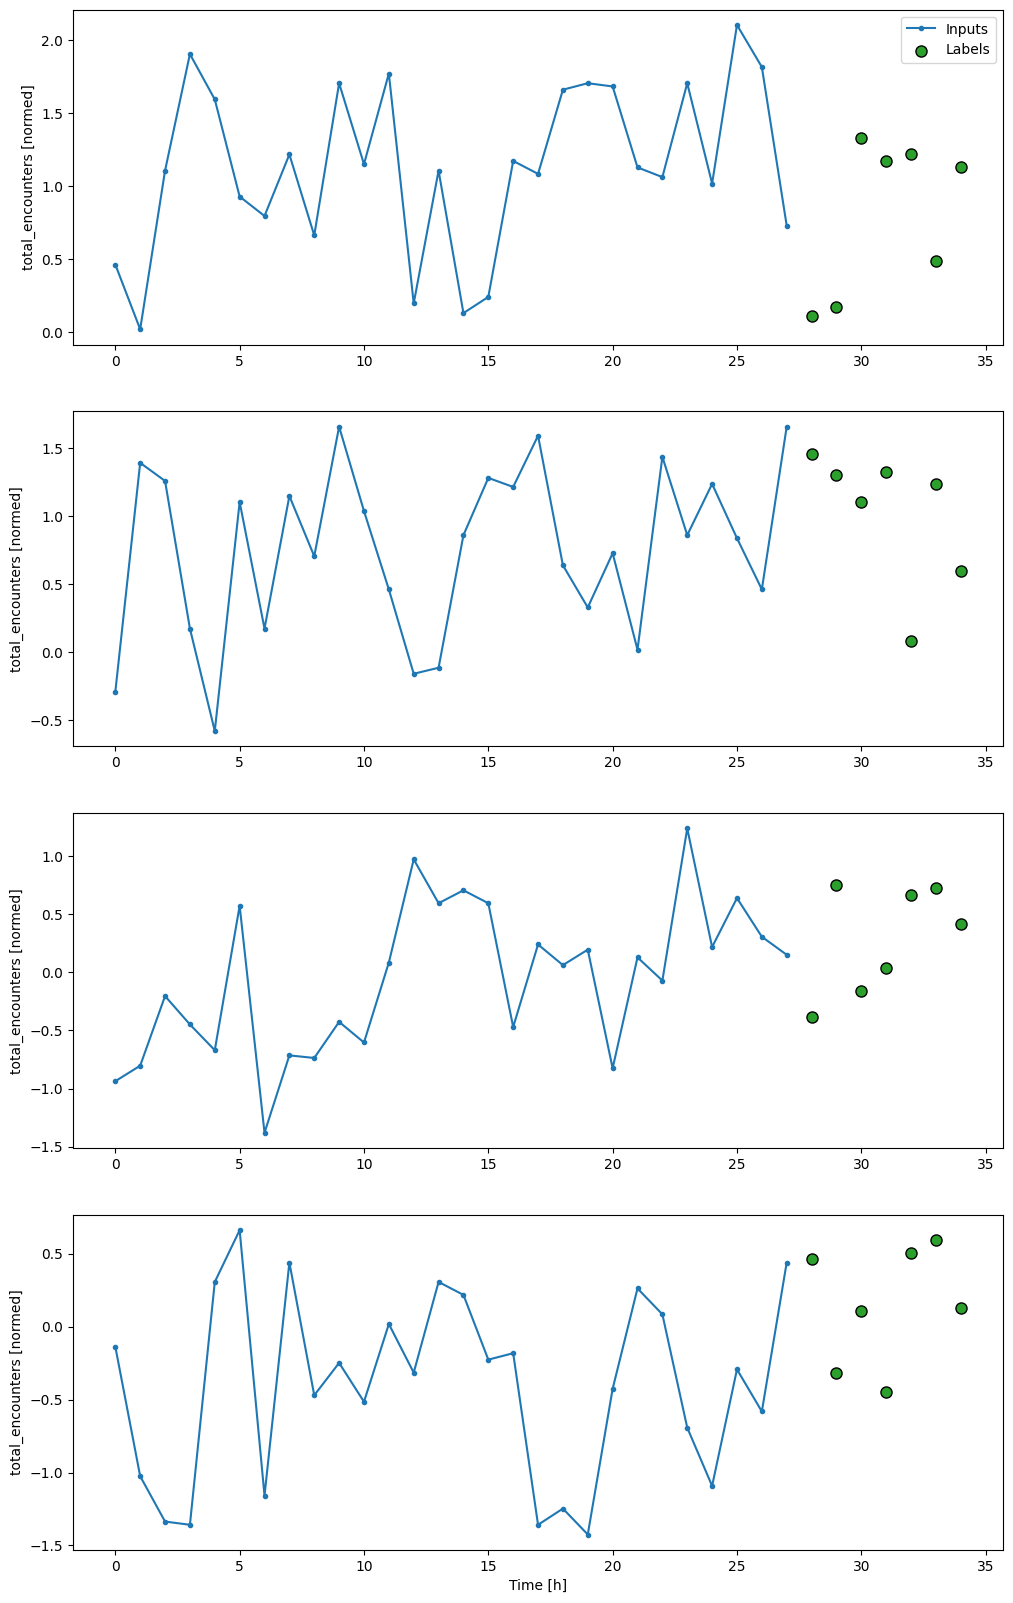

In [14]:
multi_window = WindowGenerator(input_width=LOOK_BACK,
                               label_width=OUT_STEPS,
                               shift=OUT_STEPS,
                               batch_size=BATCH_SIZE
                               )

multi_window.plot()
multi_window

In [15]:
multi_val_performance = {}
multi_performance = {}

#### CNN

##### CNN 1

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 0.8097 - mean_absolute_error: 0.7807 - val_loss: 0.5301 - val_mean_absolute_error: 0.6182
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.2347 - mean_absolute_error: 0.3280 - val_loss: 0.1541 - val_mean_absolute_error: 0.1846
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0992 - mean_absolute_error: 0.1366 - val_loss: 0.1112 - val_mean_absolute_error: 0.1507
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0723 - mean_absolute_error: 0.1059 - val_loss: 0.0756 - val_mean_absolute_error: 0.1188
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0651 - mean_absolute_error: 0.0995 - val_loss: 0.0680 - val_mean_absolute_error: 0.1090
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0639 - mean_absolute_error: 0.0967 - val_loss: 0.0656 - val_mean_absolute_error: 0.1038
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0631 - mean_absolute_error: 0.0942 - val_loss

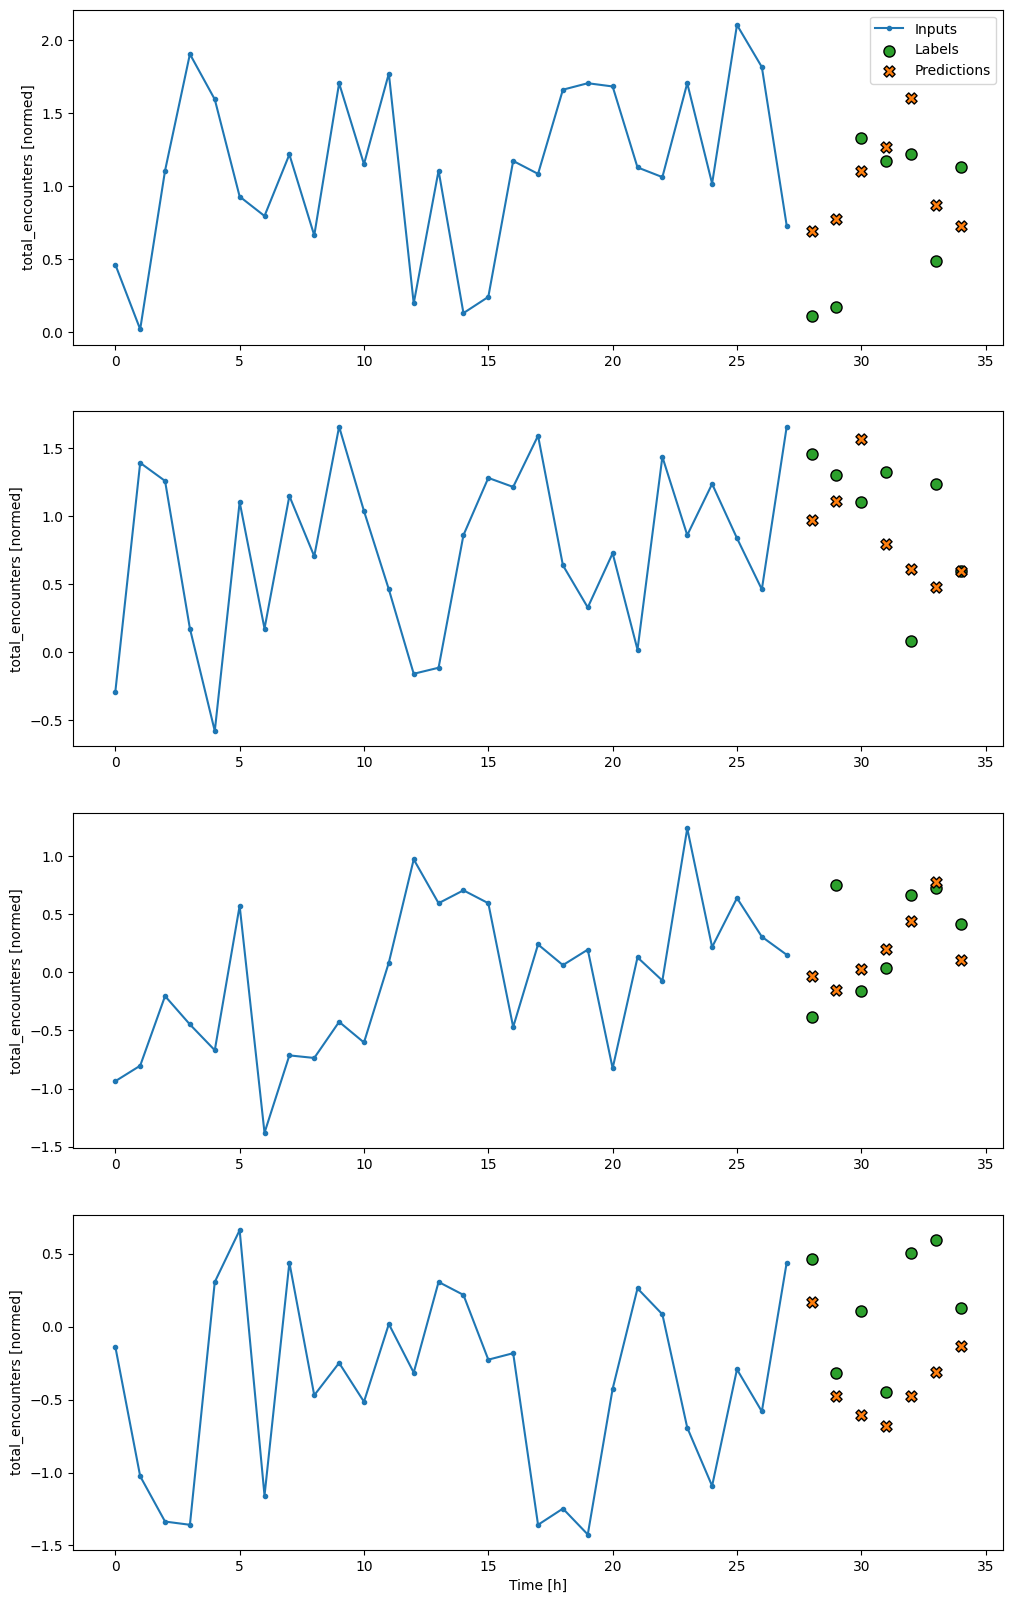

In [16]:
multi_conv_model = tf.keras.Sequential([
    # Shape [batch, time, features] => [batch, CONV_WIDTH, features]
    tf.keras.layers.Lambda(lambda x: x[:, -CONV_WIDTH:, :]),
    # Shape => [batch, 1, conv_units]
    tf.keras.layers.Conv1D(64, activation='relu', kernel_size=(CONV_WIDTH)),
    # Shape => [batch, 1,  out_steps*features]
    tf.keras.layers.Dense(OUT_STEPS*num_features,
                          kernel_initializer=tf.initializers.zeros()),
    # Shape => [batch, out_steps, features]
    tf.keras.layers.Reshape([OUT_STEPS, num_features])
])

history = compile_and_fit(multi_conv_model, multi_window, lr=LR)

# IPython.display.clear_output()
multi_val_performance['Conv'] = multi_conv_model.evaluate(multi_window.val, verbose=0, return_dict=True)
multi_performance['Conv'] = multi_conv_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(multi_conv_model)

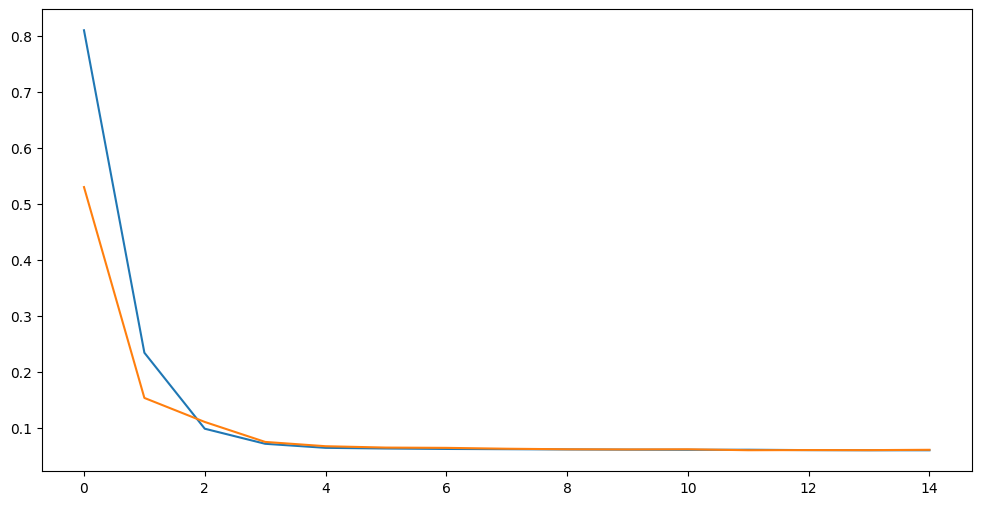

In [17]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']

plt.plot(train_losses)
plt.plot(val_losses)

plt.show()

##### CNN 2

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.8963 - mean_absolute_error: 0.8327 - val_loss: 0.7710 - val_mean_absolute_error: 0.7742
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.5815 - mean_absolute_error: 0.6630 - val_loss: 0.2809 - val_mean_absolute_error: 0.4551
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.1375 - mean_absolute_error: 0.2481 - val_loss: 0.0676 - val_mean_absolute_error: 0.1385
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0709 - mean_absolute_error: 0.1160 - val_loss: 0.0604 - val_mean_absolute_error: 0.0968
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0670 - mean_absolute_error: 0.0944 - val_loss: 0.0597 - val_mean_absolute_error: 0.0883
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0663 - mean_absolute_error: 0.0922 - val_loss: 0.0598 - val_mean_absolute_error: 0.0885
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0654 - mean_absolute_error: 0.0895 - val_loss

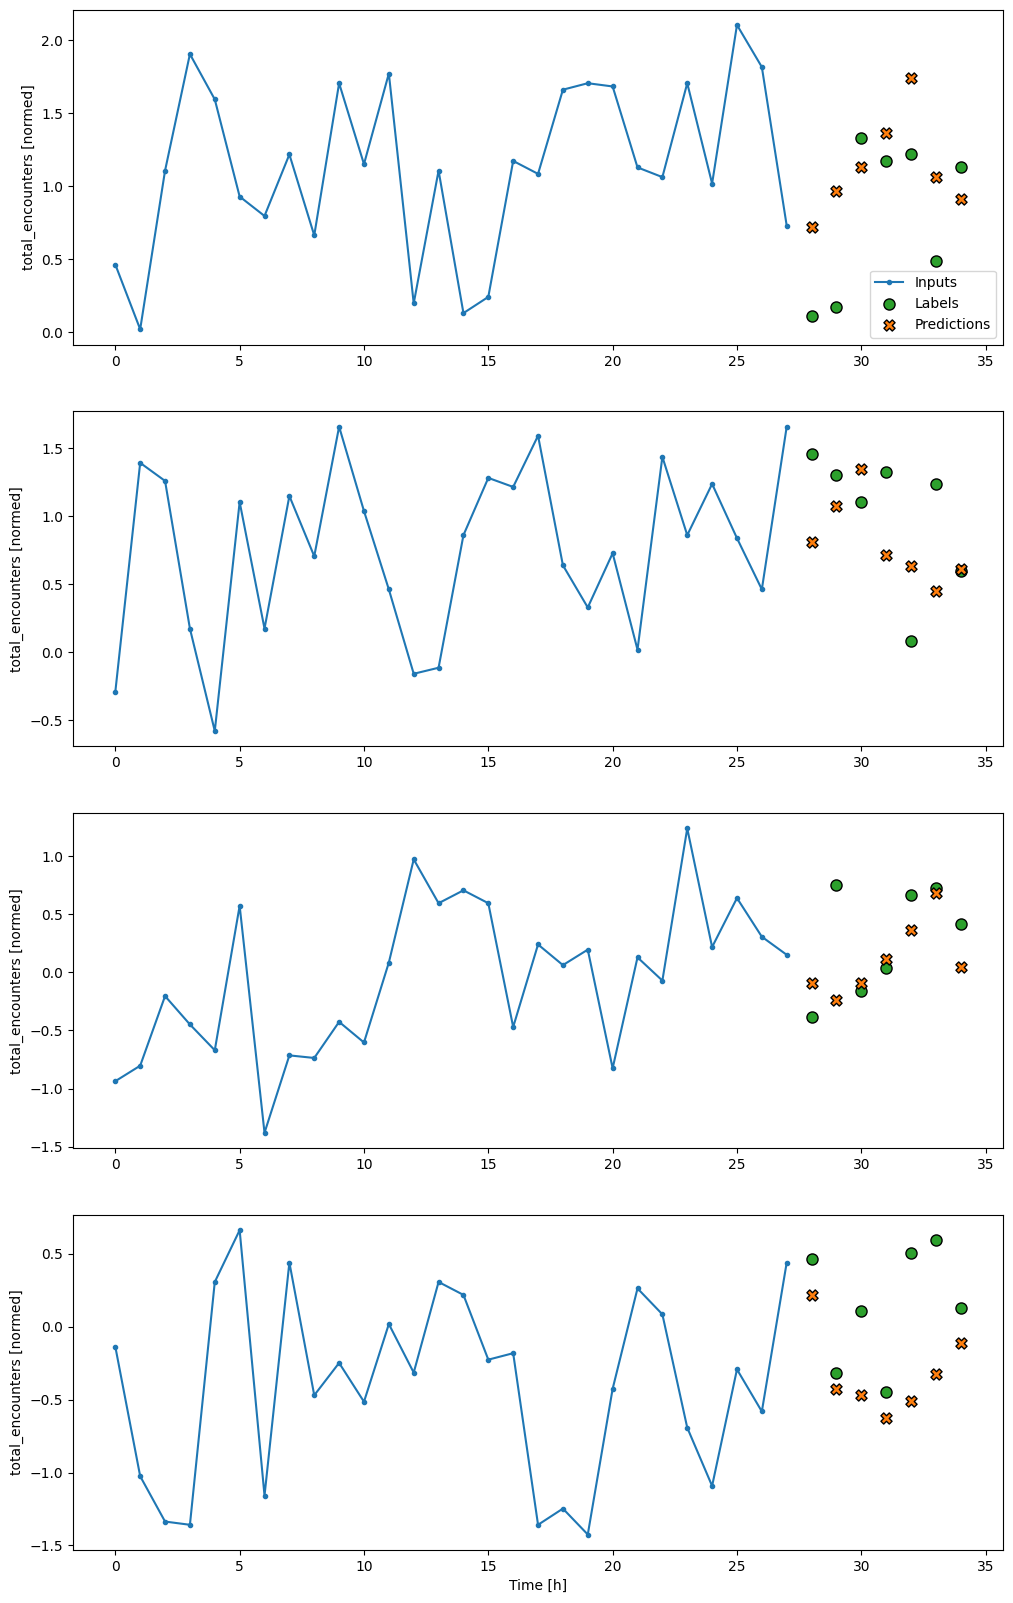

In [18]:
cnn = tf.keras.Sequential([
    tf.keras.layers.Conv1D(64, kernel_size=7, strides=1),
    # tf.keras.layers.GlobalAveragePooling1D(),
    # tf.keras.layers.Conv1D(1024, kernel_size=14, strides=7),
    tf.keras.layers.GlobalAveragePooling1D(),
    tf.keras.layers.Dense(1024, activation='tanh'),
    tf.keras.layers.Dense(7*7),
    tf.keras.layers.Reshape((7,7))

])

history = compile_and_fit(cnn, multi_window, lr=LR)

# IPython.display.clear_output()
multi_val_performance['Conv_7'] = cnn.evaluate(multi_window.val, verbose=0, return_dict=True)
multi_performance['Conv_7'] = cnn.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(cnn)


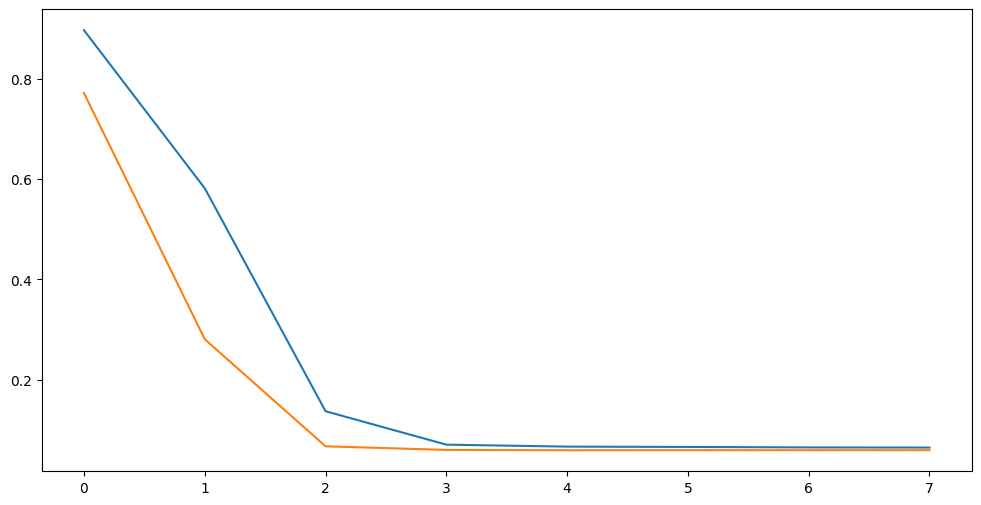

In [19]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']

plt.plot(train_losses)
plt.plot(val_losses)

plt.show()

#### AR-LSTM

Epoch 1/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 2s 12ms/step - loss: 0.9712 - mean_absolute_error: 0.8673 - val_loss: 0.9335 - val_mean_absolute_error: 0.8585
Epoch 2/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.9152 - mean_absolute_error: 0.8429 - val_loss: 0.8898 - val_mean_absolute_error: 0.8307
Epoch 3/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.8751 - mean_absolute_error: 0.8242 - val_loss: 0.8393 - val_mean_absolute_error: 0.8059
Epoch 4/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.7595 - mean_absolute_error: 0.7498 - val_loss: 0.6553 - val_mean_absolute_error: 0.6477
Epoch 5/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.5763 - mean_absolute_error: 0.5946 - val_loss: 0.5185 - val_mean_absolute_error: 0.5610
Epoch 6/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 0.4359 - mean_absolute_error: 0.5206 - val_loss: 0.3620 - val_mean_absolute_error: 0.4628
Epoch 7/100
31/31 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 0.2839 - mean_absolute_error: 0.4008 - val_los

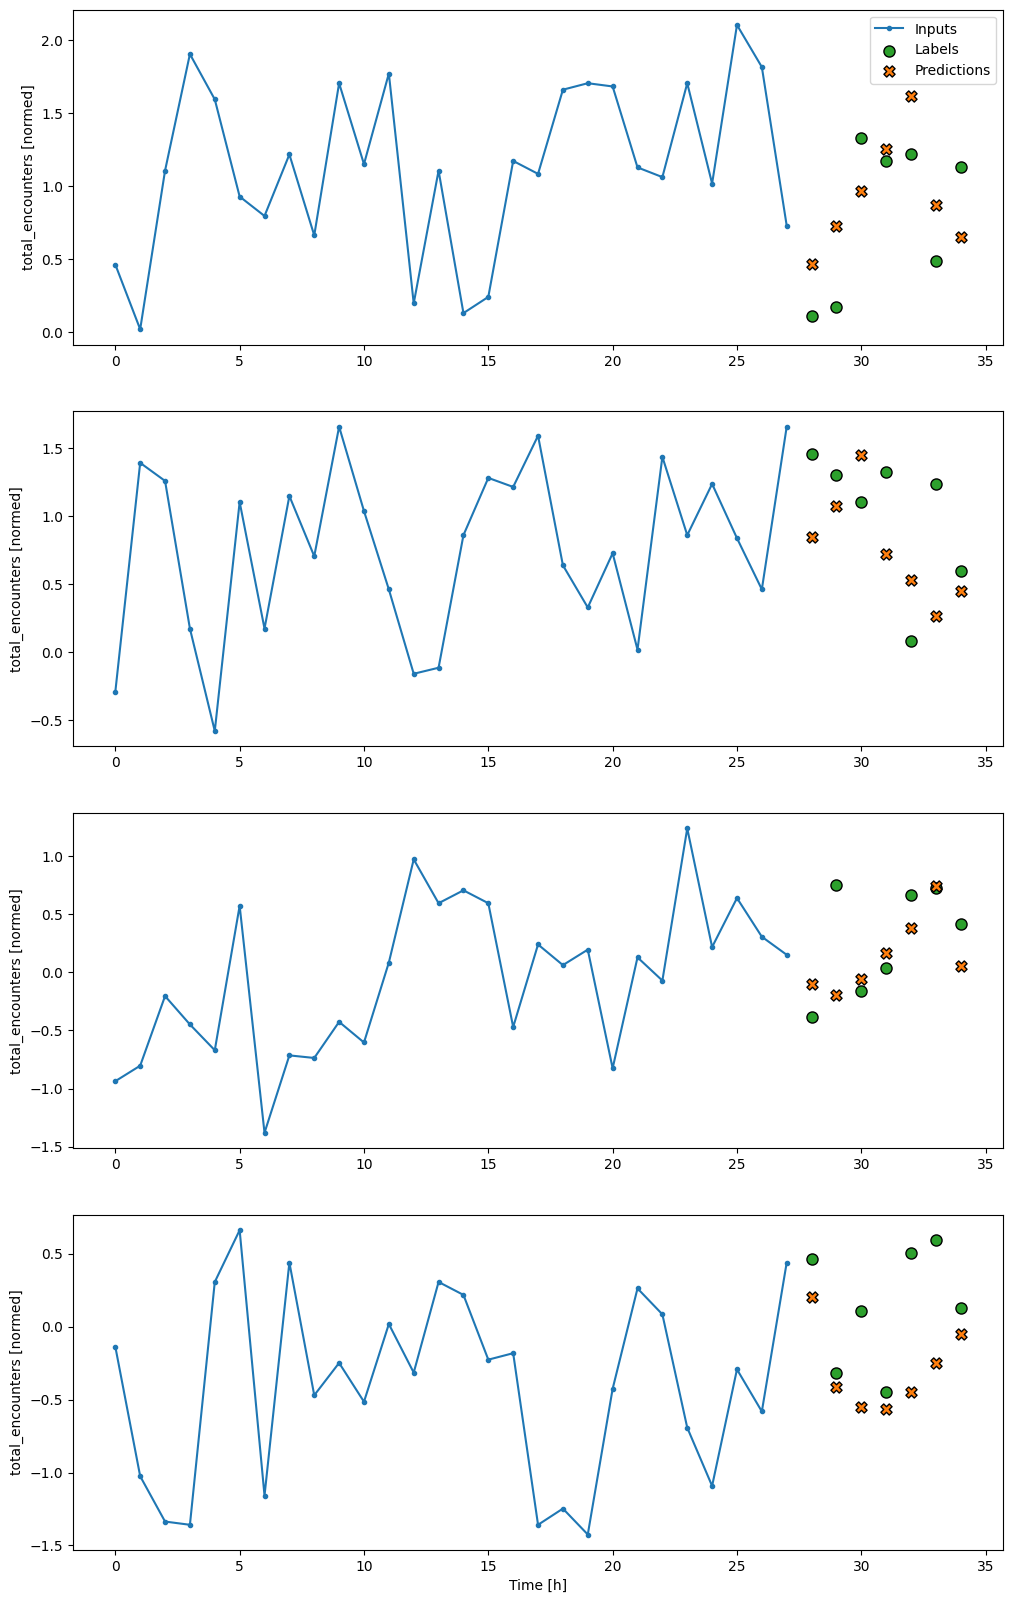

In [20]:
class FeedBack(tf.keras.Model):
  def __init__(self, units, out_steps):
    super().__init__()
    self.out_steps = out_steps
    self.units = units
    self.lstm_cell = tf.keras.layers.LSTMCell(units, activation='tanh')
    # Also wrap the LSTMCell in an RNN to simplify the `warmup` method.
    self.lstm_rnn = tf.keras.layers.RNN(self.lstm_cell, return_state=True)
    # self.dense1 = tf.keras.Sequential([
    #   tf.keras.layers.Dense(128, activation='relu'),
    #   tf.keras.layers.Dropout(0.2)
    # ])
    # self.dense2 = tf.keras.Sequential([
    #   tf.keras.layers.Dense(64, activation='relu'),
    #   tf.keras.layers.Dropout(0.2)
    # ])
    self.dense3 = tf.keras.layers.Dense(num_features)
  
  def warmup(self, inputs):
    # Encoder
    # inputs.shape => (batch, time, features)
    # x.shape => (batch, lstm_units)
    x, *state = self.lstm_rnn(inputs)

    # predictions.shape => (batch, features)
    # prediction = self.dense1(x)
    # prediction = self.dense2(prediction)
    prediction = self.dense3(x) # change x to prediction if want to uncomment previous
    return prediction, state
  
  def call(self, inputs, training=None):
    # Use a TensorArray to capture dynamically unrolled outputs.
    predictions = []
    # Initialize the LSTM state.
    prediction, state = self.warmup(inputs)

    # Insert the first prediction.
    predictions.append(prediction)

    # Run the rest of the prediction steps.
    # Decoder
    for n in range(1, self.out_steps):
      # Use the last prediction as input.
      x = prediction
      # Execute one lstm step.
      x, state = self.lstm_cell(x, states=state,
                                training=training)
      # Convert the lstm output to a prediction.
      # prediction = self.dense1(x)
      # prediction = self.dense2(prediction)
      prediction = self.dense3(x) # change x to prediction if want to uncomment previous
      # Add the prediction to the output.
      predictions.append(prediction)

    # predictions.shape => (time, batch, features)
    predictions = tf.stack(predictions)
    # predictions.shape => (batch, time, features)
    predictions = tf.transpose(predictions, [1, 0, 2])
    return predictions
  

feedback_model = FeedBack(units=UNITS, out_steps=OUT_STEPS)


history = compile_and_fit(feedback_model, multi_window, patience=2, max_epochs=MAX_EPOCHS, lr=LR)

# IPython.display.clear_output()

multi_val_performance['AR LSTM'] = feedback_model.evaluate(multi_window.val, verbose=0, return_dict=True)
multi_performance['AR LSTM'] = feedback_model.evaluate(multi_window.test, verbose=0, return_dict=True)
multi_window.plot(feedback_model)


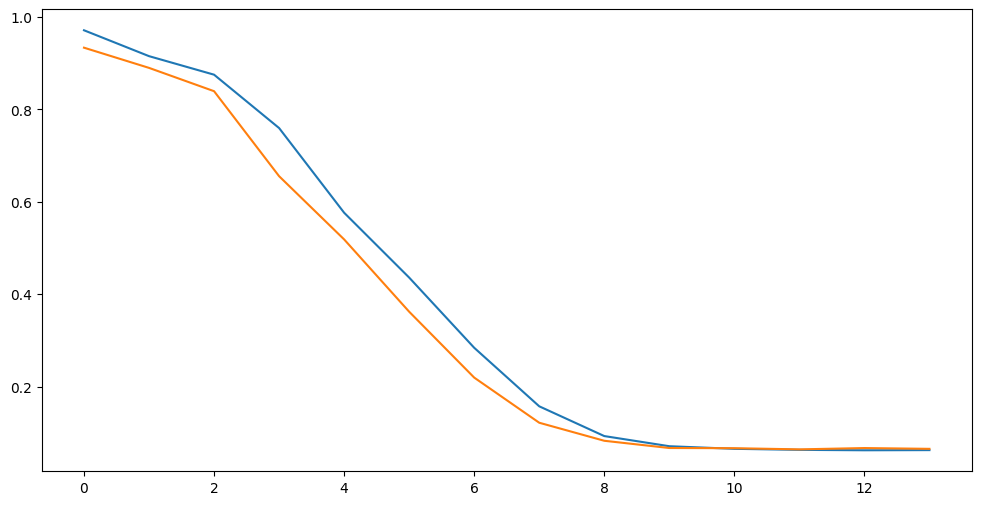

In [21]:
train_losses = history.history['loss']
val_losses = history.history['val_loss']

plt.plot(train_losses)
plt.plot(val_losses)

plt.show()

# Evaluation

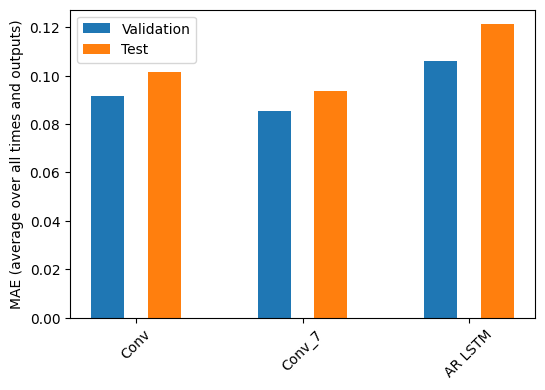

In [22]:
plt.figure(figsize=(6,4))
x = np.arange(len(multi_performance))
width = 0.2

metric_name = 'mean_absolute_error'
val_mae = [v[metric_name] for v in multi_val_performance.values()]
test_mae = [v[metric_name] for v in multi_performance.values()]

plt.bar(x - 0.17, val_mae, width, label='Validation')
plt.bar(x + 0.17, test_mae, width, label='Test')
plt.xticks(ticks=x, labels=list(multi_performance.keys()),
           rotation=45)
plt.ylabel(f'MAE (average over all times and outputs)')
_ = plt.legend()

In [23]:
multi_window.total_window_size

35

# Post processing

Reconcile with the monthly SARIMA model

In [24]:
train_dates = date_time[0:int(n*0.7)]
val_dates = date_time[int(n*0.7):int(n*0.9)]
test_dates = date_time[int(n*0.9):]

In [25]:
# sarima_daily_avgs

df_monthly = pd.read_csv('/home/uplong/Documents/DSU-analytics-comp-2026/data/grouped_by_year_month.csv',
                            parse_dates=['Date'])
filter = df_monthly[['Date', 'total_encounters']]
dictionary = filter.set_index([df_monthly['Date'].dt.month, df_monthly['Date'].dt.year]).drop('Date', axis=1).to_dict()['total_encounters']


In [26]:
import numpy as np
import pandas as pd

def boundary_reconcile(lstm_preds, dates, sarima_forecasts):
    """
    lstm_preds: np.array of 7 predictions
    dates: list of 7 pd.Timestamp objects
    sarima_forecasts: dict {(month, year): total_monthly_forecast}
    """
    reconciled_preds = np.zeros_like(lstm_preds)
    
    # 1. Identify unique months in this 7-day window
    # Example: [(1, 2026), (2, 2026)]
    unique_periods = sorted(list(set((d.month, d.year) for d in dates)))
    
    for month, year in unique_periods:
        # Find indices of the days belonging to this specific month
        mask = np.array([(d.month == month and d.year == year) for d in dates])
        
        # Calculate the SARIMA daily average for THIS specific month/year
        monthly_total = sarima_forecasts[(month, year)]
        days_in_month = pd.Period(f"{year}-{month}").days_in_month
        sarima_daily_avg = monthly_total / days_in_month
        
        # Calculate the LSTM's current daily average for this segment
        lstm_segment_avg = np.mean(lstm_preds[mask])
        
        # Calculate the scaling factor (K) for this month
        # This aligns the LSTM's 'local' level to the SARIMA's 'global' level
        k = sarima_daily_avg / lstm_segment_avg
        
        # Apply the correction only to the days in this month
        reconciled_preds[mask] = lstm_preds[mask] * k
        
    return reconciled_preds

In [27]:
int(test_df.shape[0] / 7)

40

In [59]:
from sklearn.metrics import mean_absolute_error

maes = []
maes_r = []
for moving in range(int(test_df.shape[0] / 7)-4):
    test = test_df[7*moving:multi_window.total_window_size+ (7*moving)].to_numpy(dtype=np.float32)
    input =test[:LOOK_BACK]
    label = test[LOOK_BACK:]
    preds = cnn(input[None,:,:]).numpy().squeeze(axis=0)
    p = (preds[:,0] * train_std.tolist()[0]) + train_mean.to_list()[0]
    l = (label[:,0] * train_std.tolist()[0]) + train_mean.to_list()[0]


    d = test_dates[7*moving:multi_window.total_window_size+ (7*moving)][-7:]

    r = boundary_reconcile(p, d, dictionary)

    print(p)
    print(r)
    print(l)

    maes.append(mean_absolute_error(l, p))
    maes_r.append(mean_absolute_error(l, boundary_reconcile(p, d, dictionary)))
    print('=========================')



[497.47867 471.14825 466.13992 459.08017 466.93036 473.8328  484.0903 ]
[510.94705 483.90378 478.75986 471.50897 479.5717  486.66098 497.1962 ]
[530. 469. 468. 534. 559. 543. 533.]
[517.25977 492.13806 486.06403 478.9905  487.32236 493.65012 503.98788]
[499.05426 474.81674 484.2691  477.2217  485.5228  491.82718 502.12677]
[561. 501. 500. 486. 496. 469. 475.]
[515.1677  490.80896 485.4031  478.48148 486.84497 492.78336 502.80026]
[509.95456 485.8423  480.49112 473.63953 481.9184  487.7967  497.71225]
[509. 456. 490. 483. 481. 479. 458.]
[516.7532  492.6157  486.85913 480.2909  488.80096 494.59238 504.78247]
[509.69254 485.88486 480.20694 473.72845 482.12225 487.83453 497.88538]
[498. 434. 504. 505. 465. 479. 461.]
[504.02963 480.5299  476.61496 470.27405 477.30066 482.91867 492.0644 ]
[509.0379  485.30466 481.35083 474.9469  482.04333 487.71716 496.95377]
[478. 475. 529. 514. 486. 488. 500.]
[502.85138 477.30994 472.66388 465.71606 473.52432 480.2647  490.08246]
[513.1314  487.06778 48

In [35]:
sum(maes) / len(maes)

24.594192531373764

In [61]:
sum(maes_r) / len(maes_r)


22.80811545583937

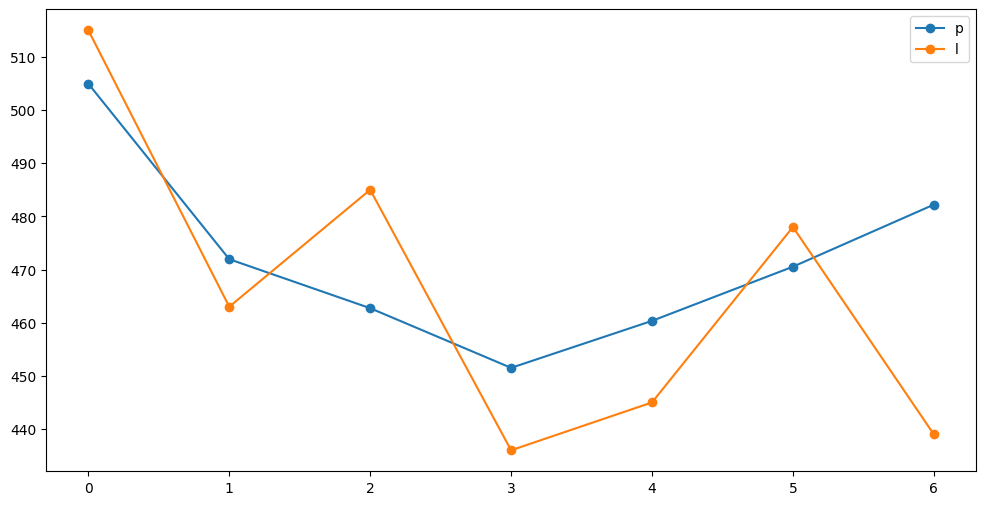

In [56]:
test = test_df[7*7:35+7*7].to_numpy(dtype=np.float32)

input = test[:LOOK_BACK]

label = test[LOOK_BACK:]
preds = feedback_model(input[None,:,:]).numpy().squeeze(axis=0)
p = (preds[:,0] * train_std.tolist()[0]) + train_mean.to_list()[0]

l = (label[:,0] * train_std.tolist()[0]) + train_mean.to_list()[0]
panos = pd.DataFrame({"p":p, "l":l})
panos.plot(marker='o')

d = test_dates[7*7:35+7*7][-7:]

In [29]:
print(p)
print(boundary_reconcile(p, d, dictionary))
print(l)

[500.9922  471.92947 462.1767  454.64655 460.28015 471.58282 481.9898 ]
[507.04343 477.6297  467.7591  460.138   465.83966 477.27884 487.81152]
[515. 463. 485. 436. 445. 478. 439.]


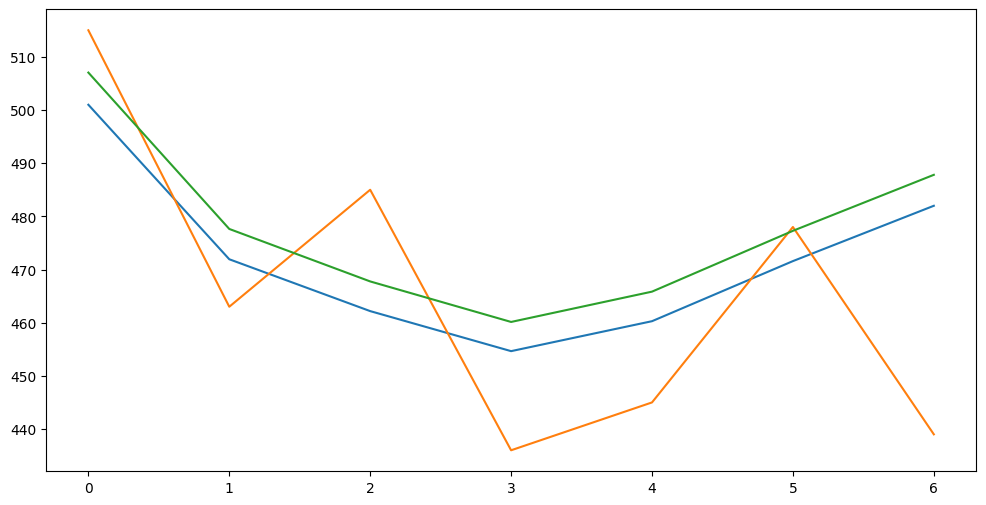

In [30]:
plt.plot(p)
plt.plot(l)
plt.plot(boundary_reconcile(p, d, dictionary))